In [7]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

MAP_NAME = "8x8"
IS_SLIPPERY = True
NUM_TRAIN_EPISODES = 10000
NUM_EVAL_EPISODES = 1000
MAX_STEPS = 100

LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.99

EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.09


In [ ]:
def train_q_learning():
    env = gym.make("FrozenLake-v1", map_name=MAP_NAME, is_slippery=IS_SLIPPERY)
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    epsilon = EPSILON_START
    rewards_history = []
    
    for episode in range(1, NUM_TRAIN_EPISODES + 1):
        state, _ = env.reset()
        done = False
        total_reward = 0
        
        for step in range(MAX_STEPS):
            if np.random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                max_q = np.max(q_table[state, :])
                best_actions = np.where(q_table[state, :] == max_q)[0]
                action = np.random.choice(best_actions)
                
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            q_target = reward + DISCOUNT_FACTOR * np.max(q_table[next_state, :])
            q_table[state, action] += LEARNING_RATE * (q_target - q_table[state, action])
            
            state = next_state
            total_reward += reward
            
            if done:
                break
                
        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
        rewards_history.append(total_reward)
        
        if episode % 1000 == 0:
            avg_win = np.mean(rewards_history[-100:]) * 100
            print(f"Episode {episode}/{NUM_TRAIN_EPISODES} | Epsilon: {epsilon:.4f} | Win Rate (last 100): {avg_win:.1f}%")
            
    env.close()
    return q_table, rewards_history

q_table, rewards_history = train_q_learning()

Episode 1000/10000 | Epsilon: 0.0100 | Win Rate (last 100): 0.0%
Episode 2000/10000 | Epsilon: 0.0100 | Win Rate (last 100): 2.0%
Episode 3000/10000 | Epsilon: 0.0100 | Win Rate (last 100): 5.0%
Episode 4000/10000 | Epsilon: 0.0100 | Win Rate (last 100): 1.0%
Episode 5000/10000 | Epsilon: 0.0100 | Win Rate (last 100): 7.0%


In [3]:
def evaluate_policy(q_table):
    env = gym.make("FrozenLake-v1", map_name=MAP_NAME, is_slippery=IS_SLIPPERY)
    successes = 0
    total_steps = 0
    
    for episode in range(NUM_EVAL_EPISODES):
        state, _ = env.reset()
        done = False
        
        while not done:
            action = np.argmax(q_table[state, :])
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            total_steps += 1
            if terminated and reward == 1.0:
                successes += 1
                
    env.close()
    
    print(f"Evaluation Success Rate: {(successes / NUM_EVAL_EPISODES) * 100:.2f}%")
    print(f"Average Steps: {total_steps / NUM_EVAL_EPISODES:.2f}")

evaluate_policy(q_table)

Evaluation Success Rate: 58.90%
Average Steps: 73.48


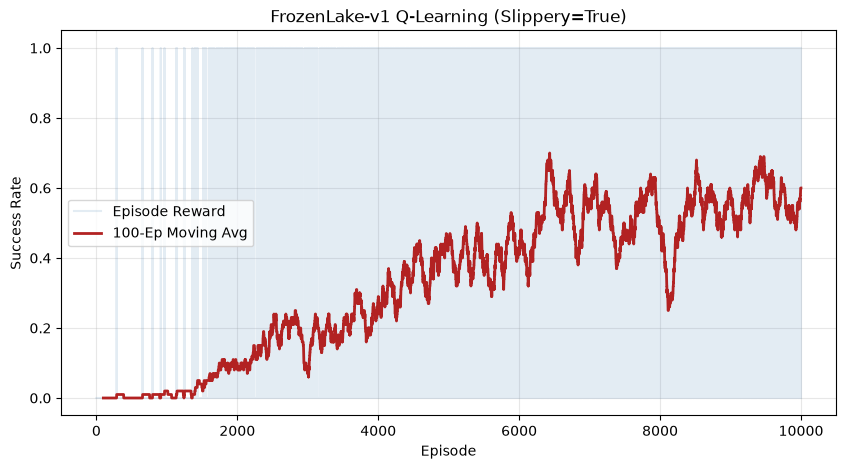

In [5]:
window_size = 100
moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(rewards_history, alpha=0.15, color='steelblue', label='Episode Reward')
plt.plot(np.arange(window_size - 1, len(rewards_history)), moving_avg, color='firebrick', linewidth=2, label=f'{window_size}-Ep Moving Avg')
plt.title(f'FrozenLake-v1 Q-Learning (Slippery={IS_SLIPPERY})')
plt.xlabel('Episode')
plt.ylabel('Success Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()